In [1]:
import numpy as np
import pyvista as pv
from pyvista import examples

/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


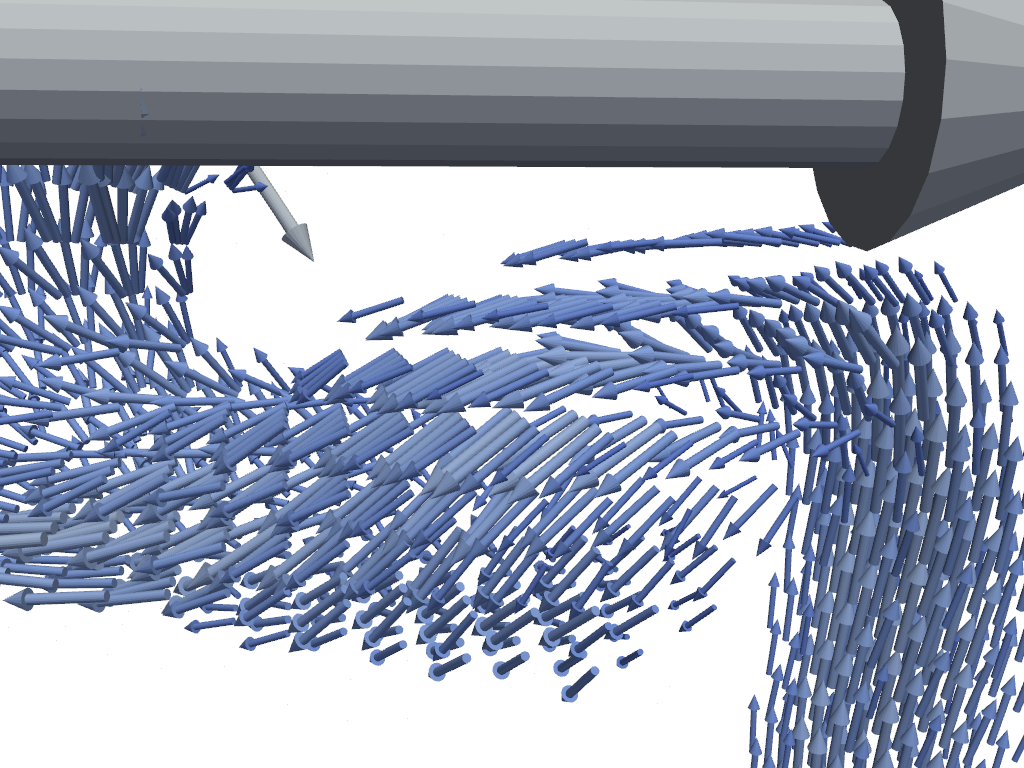

In [2]:
mesh = examples.download_carotid().threshold(145, scalars="scalars")
mask = mesh['scalars'] < 210
mesh['scalars'][mask] = 0  # null out smaller vectors

# Make a geometric object to use as the glyph
geom = pv.Arrow()  # This could be any dataset

# Perform the glyph
glyphs = mesh.glyph(orient="vectors", scale="vectors", factor=0.3, geom=geom)

# plot using the plotting class
pl = pv.Plotter()
pl.add_mesh(glyphs, show_scalar_bar=False, lighting=True, cmap='coolwarm')
pl.camera_position = [
    (146.53, 91.28, 21.70),
    (125.00, 94.45, 19.81),
    (-0.086, 0.007, 0.996),
]  # view only part of the vector field
cpos = pl.show(return_cpos=True)

/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


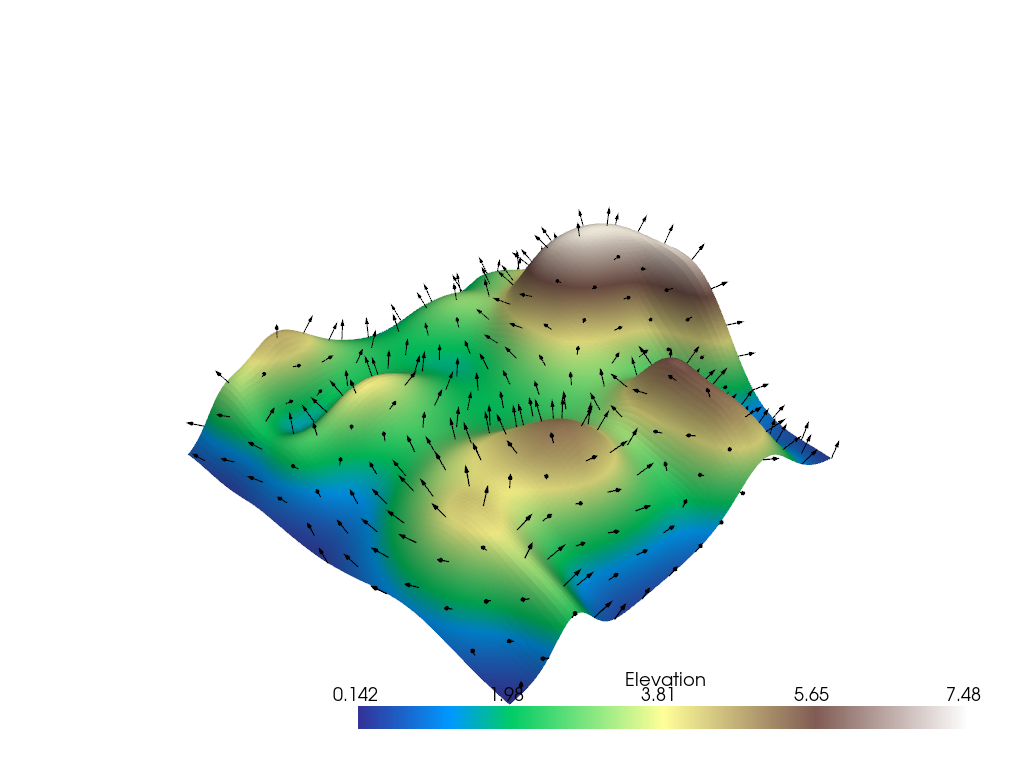

In [3]:
# Example dataset with normals
mesh = examples.load_random_hills()

# create a subset of arrows using the glyph filter
arrows = mesh.glyph(scale="Normals", orient="Normals", tolerance=0.05)

p = pv.Plotter()
p.add_mesh(arrows, color="black")
p.add_mesh(mesh, scalars="Elevation", cmap="terrain")
p.show()

/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


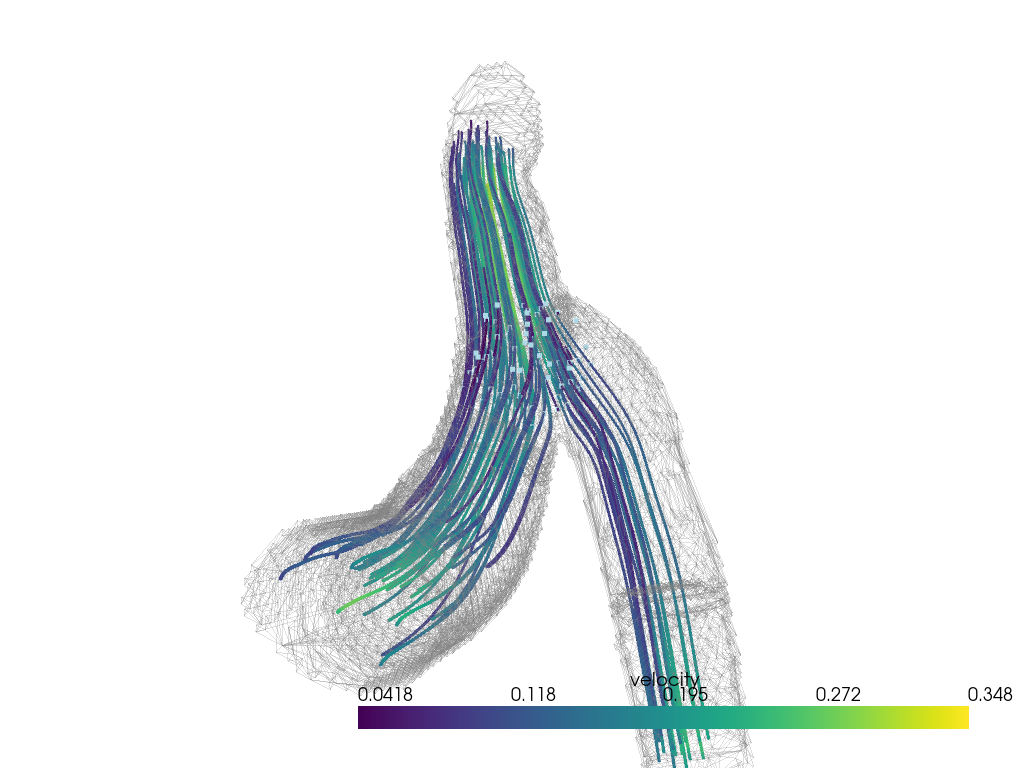

In [4]:
mesh = examples.download_blood_vessels().cell_data_to_point_data()
mesh.set_active_scalars("velocity")
streamlines, src = mesh.streamlines(
    return_source=True, source_radius=10, source_center=(92.46, 74.37, 135.5)
)

boundary = mesh.decimate_boundary().extract_all_edges()

p = pv.Plotter()
p.add_mesh(streamlines.tube(radius=0.2), lighting=False)
p.add_mesh(src)
p.add_mesh(boundary, color="grey", opacity=0.25)
p.camera_position = [(10, 9.5, -43), (87.0, 73.5, 123.0), (-0.5, -0.7, 0.5)]
p.show()

/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/opt/miniconda3/envs/data-viz-2025/lib/python3.10/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


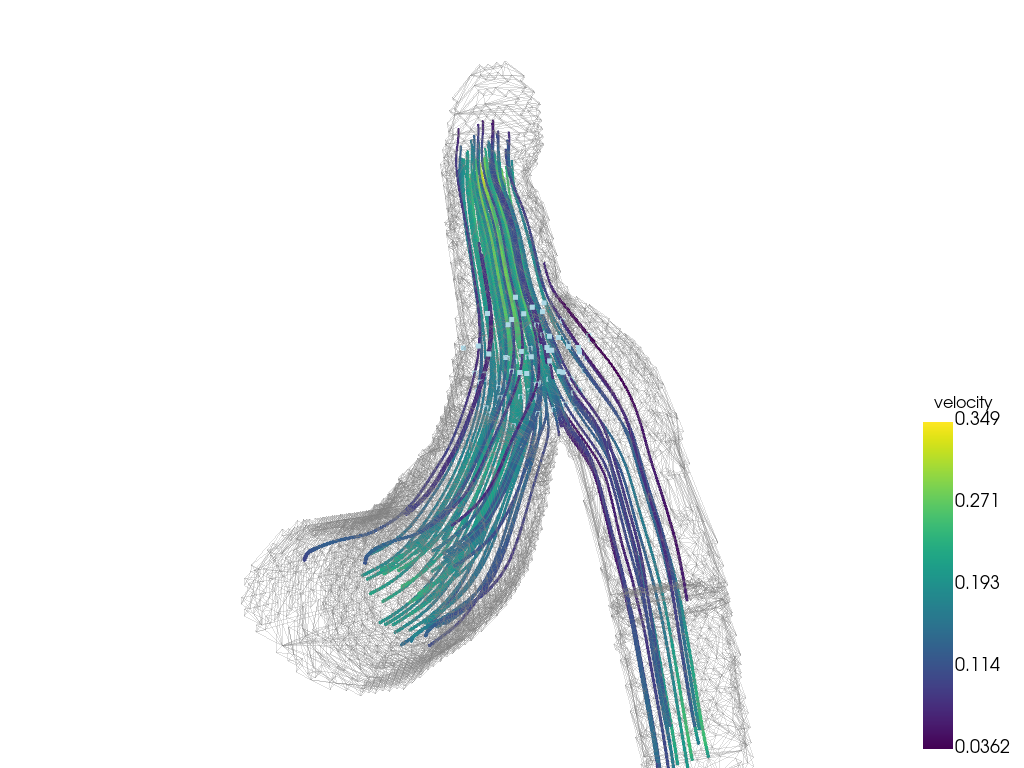

In [5]:
mesh = examples.download_blood_vessels().cell_data_to_point_data()
mesh.set_active_scalars("velocity")
streamlines, src = mesh.streamlines(
    return_source=True, source_radius=10, source_center=(92.46, 74.37, 135.5)
)

boundary = mesh.decimate_boundary().extract_all_edges()

sargs = dict(vertical=True, title_font_size=16) ### <<== new wrt previous one
p = pv.Plotter()
p.add_mesh(streamlines.tube(radius=0.2), lighting=False, scalar_bar_args=sargs)
p.add_mesh(src)
p.add_mesh(boundary, color="grey", opacity=0.25)
p.camera_position = [(10, 9.5, -43), (87.0, 73.5, 123.0), (-0.5, -0.7, 0.5)]
p.show()
